In [3]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
from lmfit import Parameters, minimize

import psyduck.fit_toolbox
from psyduck.operations import get_spin_operators
from psyduck.hamiltonians import (quadrupole_hamiltonian_from_Vab, zeeman_hamiltonian,
                                   hyperfine_hamiltonian, get_fq1, get_fq2, get_quadrupole_stark_shift)
from psyduck.tensors import get_R_tensor, voigt_to_tensor
from psyduck.plotting import plot_quadrupole_tensor, spherical_plot_3d, spherical_plot_hammer, spherical_plot_3d_with_projections

In [4]:
V_ab = np.load('V_ab_fit.npy')

In [9]:
# Physical constants for neutral Sb-123 donor in Si
I_SPIN        = 7/2
S_SPIN        = 1/2
Q_N           = -0.69e-28        # Nuclear quadrupole moment (C·m²)
GAMMA_NUCLEAR = 5.55e6           # Nuclear gyromagnetic ratio (Hz/T) — Sb-123
GAMMA_ELECTRON = 28.024951e9     # Electron gyromagnetic ratio (Hz/T), g≈2
A_HF          = 97.5e6         # Isotropic hyperfine coupling (Hz) — Sb-123 in Si

# B0 must match the field used during the ionized tensor extraction.
# Typical value from NMR data: B0 = mean_NMR_freq / GAMMA_NUCLEAR
B0 = 0.934                       # (T) — adjust to match your experiment

In [10]:
# Pre-compute the hyperfine term (theta-independent, acts on full 16-dim space)
_H_hf = hyperfine_hamiltonian(S_SPIN, I_SPIN, A_HF)
_H_q  = quadrupole_hamiltonian_from_Vab(I_SPIN, V_ab, Q_N)

def neutral_hamiltonian(theta, phi=0.0):
    """Full 16-dimensional neutral-donor Hamiltonian (electron ⊗ nucleus).

    H = H_Z^e + H_Z^n + H_quadrupole + H_hyperfine

    Eigenvalues split into two groups of 8 separated by ~γ_e B0 ≈ 28 GHz:
      lower 8  → ms = +1/2 manifold  (effective nuclear freq ≈ A/2 - γ_n B0)
      upper 8  → ms = -1/2 manifold  (effective nuclear freq ≈ A/2 + γ_n B0)
    """
    H_ze = qt.tensor(zeeman_hamiltonian(S_SPIN, B0, gamma=GAMMA_ELECTRON, theta=theta, phi=phi),
                     qt.qeye(int(2*I_SPIN + 1)))
    H_zn = qt.tensor(qt.qeye(2),
                     zeeman_hamiltonian(I_SPIN, B0, gamma=GAMMA_NUCLEAR, theta=theta, phi=phi))
    H_qn = qt.tensor(qt.qeye(2), _H_q)
    return H_ze + H_zn + H_qn + _H_hf

In [11]:
# Predict NMR transition frequencies and quadrupole splittings at theta = pi/2
theta_demo = np.pi / 2
evals = neutral_hamiltonian(theta_demo).eigenstates()[0]

# The 16 eigenvalues split into two groups of 8 separated by ~γ_e B0
evals_up   = evals[:8]   # ms = +1/2 manifold (lower energy)
evals_down = evals[8:]   # ms = -1/2 manifold (higher energy)

nmr_up   = np.diff(evals_up)    * 1e-6   # MHz
nmr_down = np.diff(evals_down)  * 1e-6   # MHz

print(f'theta = {theta_demo/np.pi:.2f}π')
print()
print('ms = +1/2 manifold')
print(f'  NMR transitions (MHz): {nmr_up}')
print(f'  fq1 = {np.mean(np.diff(nmr_up)):.4f} MHz    (= mean 2nd diff)')
print(f'  fq2 = {np.mean(np.diff(np.diff(nmr_up))):.6f} MHz    (= mean 3rd diff)')
print()
print('ms = -1/2 manifold')
print(f'  NMR transitions (MHz): {nmr_down}')
print(f'  fq1 = {np.mean(np.diff(nmr_down)):.4f} MHz')
print(f'  fq2 = {np.mean(np.diff(np.diff(nmr_down))):.6f} MHz')

theta = 0.50π

ms = +1/2 manifold
  NMR transitions (MHz): [43.20091242 43.34927104 43.49961934 43.65199386 43.80643211 43.9629726
 44.12165488]
  fq1 = 0.1535 MHz    (= mean 2nd diff)
  fq2 = 0.002065 MHz    (= mean 3rd diff)

ms = -1/2 manifold
  NMR transitions (MHz): [54.47632352 54.26140586 54.04858745 53.8378297  53.62909502 53.42234677
 53.21754927]
  fq1 = -0.2098 MHz
  fq2 = 0.002024 MHz


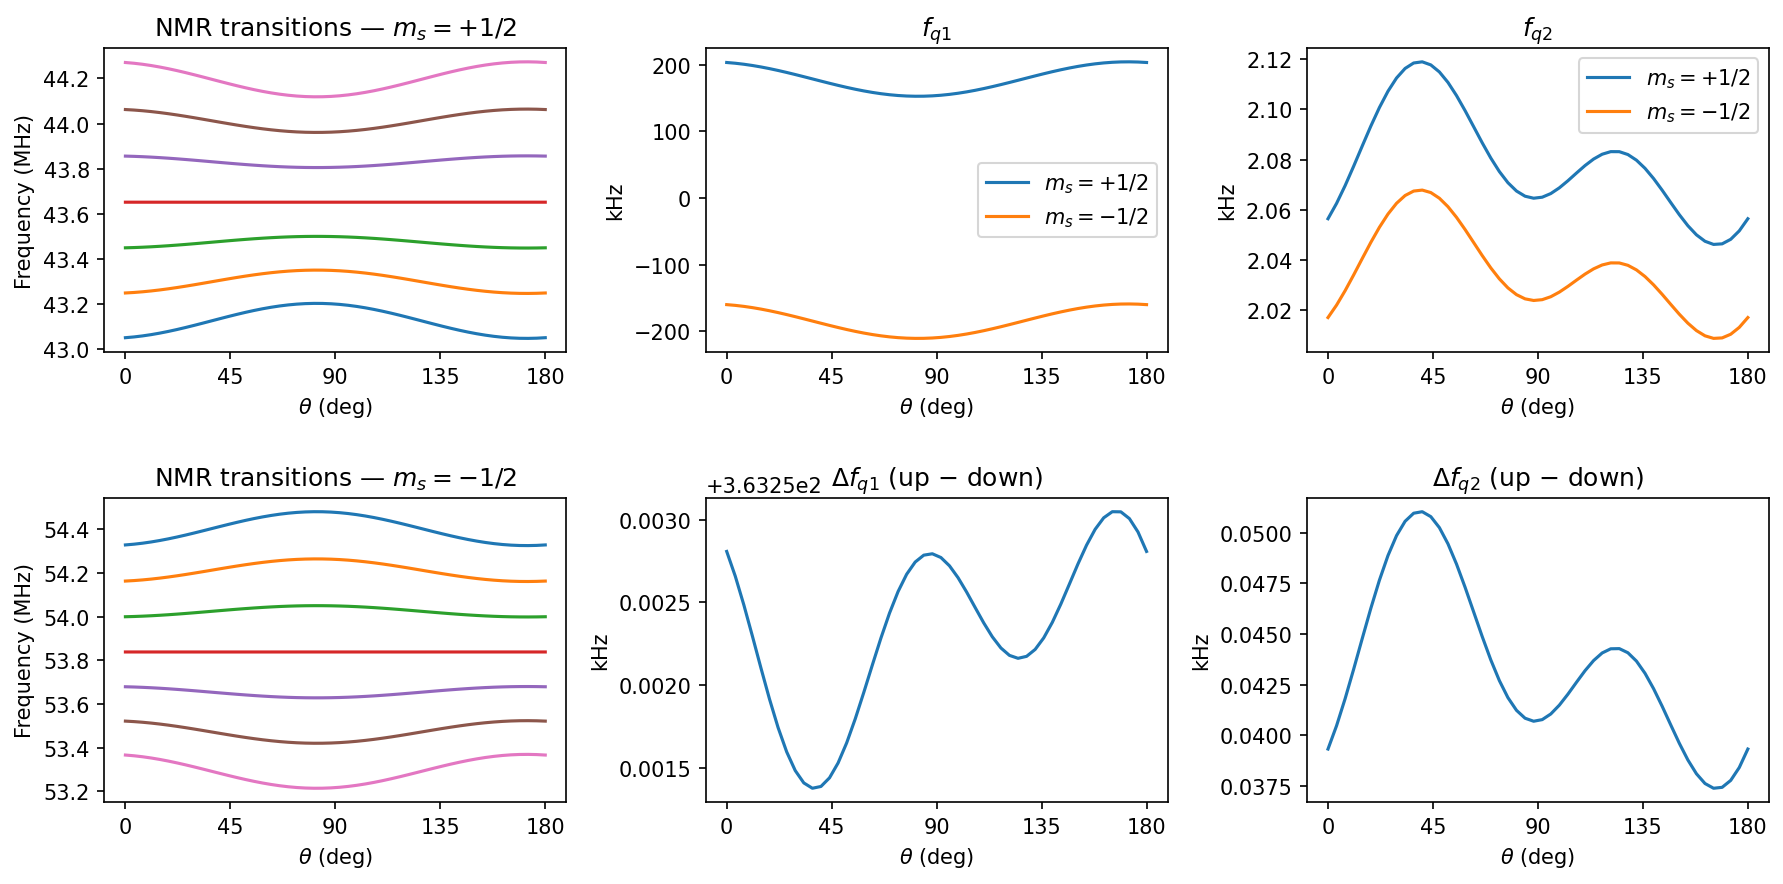

In [12]:
# Sweep theta and compute NMR frequencies + quadrupole splittings for both manifolds
thetas = np.linspace(0, np.pi, 50)

nmr_up_arr   = np.zeros((len(thetas), 7))   # 7 transitions for I=7/2
nmr_down_arr = np.zeros((len(thetas), 7))
fq1_up   = np.zeros(len(thetas))
fq2_up   = np.zeros(len(thetas))
fq1_down = np.zeros(len(thetas))
fq2_down = np.zeros(len(thetas))

for t, theta in enumerate(thetas):
    evals = neutral_hamiltonian(theta).eigenstates()[0]
    ev_up   = evals[:8]
    ev_down = evals[8:]
    nmr_up_arr[t]   = np.diff(ev_up)
    nmr_down_arr[t] = np.diff(ev_down)
    fq1_up[t]   = np.mean(np.diff(np.diff(ev_up)))
    fq2_up[t]   = np.mean(np.diff(np.diff(np.diff(ev_up))))
    fq1_down[t] = np.mean(np.diff(np.diff(ev_down)))
    fq2_down[t] = np.mean(np.diff(np.diff(np.diff(ev_down))))

theta_deg = thetas / np.pi * 180
colors = plt.cm.tab10.colors

fig, axes = plt.subplots(2, 3, figsize=(12, 6), dpi=150)

# NMR transitions — ms=+1/2
for i in range(7):
    axes[0, 0].plot(theta_deg, nmr_up_arr[:, i] * 1e-6, color=colors[i])
axes[0, 0].set_title('NMR transitions — $m_s = +1/2$')
axes[0, 0].set_ylabel('Frequency (MHz)')

# NMR transitions — ms=-1/2
for i in range(7):
    axes[1, 0].plot(theta_deg, nmr_down_arr[:, i] * 1e-6, color=colors[i])
axes[1, 0].set_title('NMR transitions — $m_s = -1/2$')
axes[1, 0].set_ylabel('Frequency (MHz)')

# fq1
axes[0, 1].plot(theta_deg, fq1_up   * 1e-3, label='$m_s=+1/2$')
axes[0, 1].plot(theta_deg, fq1_down * 1e-3, label='$m_s=-1/2$')
axes[0, 1].set_title('$f_{q1}$')
axes[0, 1].set_ylabel('kHz')
axes[0, 1].legend()

# fq2
axes[0, 2].plot(theta_deg, fq2_up   * 1e-3, label='$m_s=+1/2$')
axes[0, 2].plot(theta_deg, fq2_down * 1e-3, label='$m_s=-1/2$')
axes[0, 2].set_title('$f_{q2}$')
axes[0, 2].set_ylabel('kHz')
axes[0, 2].legend()

# fq1 difference between manifolds (hyperfine-induced asymmetry)
axes[1, 1].plot(theta_deg, (fq1_up - fq1_down) * 1e-3)
axes[1, 1].set_title('$\\Delta f_{q1}$ (up $-$ down)')
axes[1, 1].set_ylabel('kHz')

axes[1, 2].plot(theta_deg, (fq2_up - fq2_down) * 1e-3)
axes[1, 2].set_title('$\\Delta f_{q2}$ (up $-$ down)')
axes[1, 2].set_ylabel('kHz')

for a in axes.flat:
    a.set_xlabel(r'$\theta$ (deg)')
    a.set_xticks([0, 45, 90, 135, 180])

fig.tight_layout()
plt.savefig('neutral_nmr_predictions.png', dpi=300)

In [14]:
fq1_up[len(fq1_up)//2]

np.float64(153965.9116566976)

In [17]:
fq1_down[len(fq1_down)//2]

np.float64(-209286.85892136893)